In [11]:
from typing_extensions import TypedDict
from typing import Annotated, Literal, List, Dict, Any
from operator import add
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model




llm = init_chat_model("openai:gpt-4o")


In [12]:
class State(TypedDict):
    ask: str
    needs: List[str]          
    codes: Annotated[List[Dict[str, Any]], add]  
    passed: bool     
    final_code: str
    
   

In [13]:
def analyze_ask(state:State):
    response = llm.invoke(
        f"어떤 종류의 파이썬 코딩이 필요한지 분석해줘:{state['ask']}"
    )
    return {
        "needs":[
            {
                "need":response.content,                
    }
    ]
    }

def simple_coder(state:State):
    response = llm.invoke(
        f"필요한 파이썬 코딩을 간단하게 구현해줘:{state['needs']}"
    )
    return {
        "codes":[
            {
                "code":response.content,                
    }
    ]
    }
def do_coder(state:State):
    response = llm.invoke(
        f"필요한 파이썬 코딩을 꼭 실행이 되게 구현해줘:{state['needs']}"
    )
    return {
        "codes":[
            {
                "code":response.content,                
    }
    ]
    }
def easy_coder(state:State):
    response = llm.invoke(
        f"필요한 파이썬 코딩을 누구나 이해하기 쉽게 구현해줘:{state['needs']}"
    )
    return {
        "codes":[
            {
                "code":response.content,                
    }
    ]
    }

def collect(state: State):
    return {}

def has_three_codes(state: State) -> bool:
    return len(state["codes"]) >= 3

def evaluator(state : State):
    response = llm.invoke(f"""출력된 3개 파이썬 코딩을 평가해줘, 
                          평가항목은 1. 간단하게 만들었는지 2. 작동이 되는지, 3. 누구나 이해할 수 있는지 
                          이 세가지 평가항목을 종합적으로 100점만점으로 평가해서 70점이상은 PASS, 70점 이하는 FAIL이야
                          다만 실행이 안되면 무조건 0점이야 
                          {state["codes"]}
                            그리고 세개 코드중 하나가 통과하면 그 하나에 코드에 반드시 마지막 줄에 반드시'pass:PASS' 또는 'pass:FAIL'를 써줘
                            """)
    text = response.content
    passed = "pass:PASS" in text
    return {
        "final_code": text,
        "passed":passed
    }

def evaluate_code(state: State) -> bool:
    return state["passed"]

def save_code(state: State):
    code = state["final_code"]

    with open("generated_code.py", "w", encoding="utf-8") as f:
        f.write(code)

    return {}


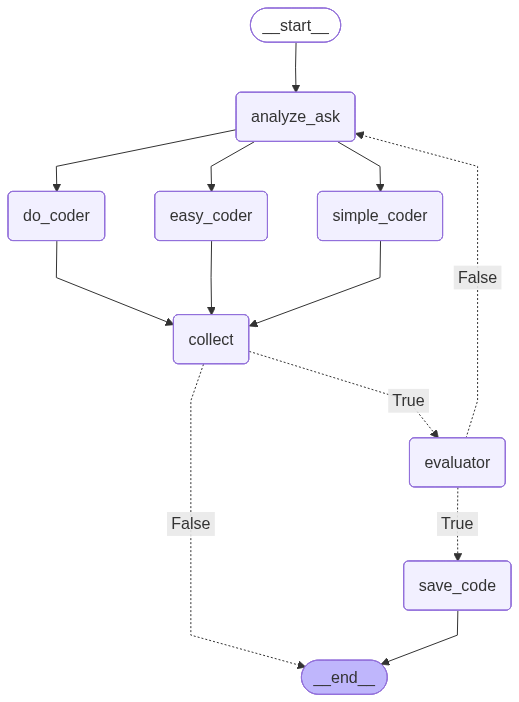

In [14]:
graph_builder = StateGraph(State)

graph_builder.add_node("analyze_ask",analyze_ask)
graph_builder.add_node("simple_coder",simple_coder)
graph_builder.add_node("do_coder",do_coder)
graph_builder.add_node("easy_coder",easy_coder)
graph_builder.add_node("collect",collect)
graph_builder.add_node("evaluator",evaluator)
graph_builder.add_node("save_code", save_code)


graph_builder.add_edge(START,"analyze_ask")
graph_builder.add_edge("analyze_ask","simple_coder")
graph_builder.add_edge("analyze_ask","do_coder")
graph_builder.add_edge("analyze_ask","easy_coder")
graph_builder.add_edge("simple_coder","collect")
graph_builder.add_edge("do_coder","collect")
graph_builder.add_edge("easy_coder","collect")
graph_builder.add_conditional_edges("collect",has_three_codes,
    {True: "evaluator", False: END}
)
graph_builder.add_conditional_edges(
    "evaluator",
    evaluate_code,
    {True: "save_code", False: "analyze_ask"}
)

graph_builder.add_edge("save_code", END)

graph = graph_builder.compile()
graph

In [15]:
graph.invoke({
    "ask":"바로 사용할 수 있는 계산기 코드 짜줘"
})

{'ask': '바로 사용할 수 있는 계산기 코드 짜줘',
 'needs': [{'need': '계산기를 만드는 것은 파이썬 프로그래밍의 기초적인 예제 중 하나입니다. 만약 간단한 콘솔 기반의 사칙연산 계산기를 원하신다면, 아래와 같은 코드로 구현할 수 있습니다.\n\n```python\ndef add(x, y):\n    return x + y\n\ndef subtract(x, y):\n    return x - y\n\ndef multiply(x, y):\n    return x * y\n\ndef divide(x, y):\n    if y == 0:\n        return "Error: Division by zero"\n    return x / y\n\ndef calculator():\n    print("Welcome to the simple calculator!")\n    print("Select operation:")\n    print("1. Add")\n    print("2. Subtract")\n    print("3. Multiply")\n    print("4. Divide")\n\n    while True:\n        choice = input("Enter choice (1/2/3/4): ")\n\n        if choice in [\'1\', \'2\', \'3\', \'4\']:\n            try:\n                num1 = float(input("Enter first number: "))\n                num2 = float(input("Enter second number: "))\n            except ValueError:\n                print("Invalid input. Please enter numbers only.")\n                continue\n\n            if choice == \'1\':\n